In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import re
import os.path as op
from typing import Tuple, Iterator
# EEG utilities
# import mne
# BIDS utilities
# from util.io.bids import DataSink
# from bids import BIDSLayout
# PLV functions
# from util.io.ffr import read_epochs
# from util.io.plv import *
from scipy.stats import shapiro, mannwhitneyu
from arch.bootstrap import IIDBootstrap

In [13]:
# Functions for computing effects sizes for mann-whitney U
def Z_from_U(n1, n2, U):
    mean_U = n1 * n2 / 2
    sd_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    
    z = (U - mean_U) / sd_U
    return z

def cohens_r(n1, n2, z):
    N = n1 + n2
    r = z / np.sqrt(N)
    return r

### Load data

In [14]:
# fpaths = glob.glob('../data/bids/derivatives/plv/sub-*/*.csv')

# plvs = pd.DataFrame()
# for fpath in fpaths:
#     plvs = pd.concat([plvs, pd.read_csv(fpath, index_col = False)], ignore_index = True)

In [15]:
# Regenerate null, but in a dataframe
np.random.seed(42)
draws = 1000
subs = 5000
null = np.array([])

for i in range(subs):
    plvs = list()
    for j in range(draws):
        # Draw random phases from a uniform distribution
        phases = np.random.uniform(low = 0, high = 2*np.pi, size = 400)
        plv = np.abs(np.mean(np.exp(1j * phases)))
        plvs.append(plv)
    mean_plv = np.mean(plvs)
    null = np.append(null, mean_plv)


# Get 95% CI
CI90 = np.percentile(null, 90)
print(f'90% CI: {CI90}')
CI95 = np.percentile(null, 95)
print(f'95% CI: {CI95}')

# Create null dataframe
null = pd.DataFrame({
    'subj': 'null',
    'accuracy_group': 'null',
    'plv': null,
    'stim_freq': 'null'
})

90% CI: 0.045248571122808376
95% CI: 0.04552272363434129


In [16]:
# fpaths = glob.glob('../data/bids/derivatives/plv/sub-*/*.csv')
# plvs = pd.DataFrame()
# for fpath in fpaths:
#     plvs = pd.concat([plvs, pd.read_csv(fpath, index_col = False)], ignore_index = True)

In [17]:
# # Add accuracy group to dataframe
# accuracy = pd.read_csv('accuracy.csv', index_col = 0)
# accuracy = accuracy.rename(columns = {'subject': 'subj', 'score_group': 'accuracy_group'})
# plvs = plvs.rename(columns = {'sub': 'subj'})
# plvs = plvs.merge(accuracy, left_on = ["subj"], right_on = ["subj"])
# plvs.to_csv('plvs-accuracy.csv', index = False)
# plvs

In [18]:
palette_tab10 = sns.color_palette("tab10", 10)

In [19]:
plvs = pd.read_csv('plvs-accuracy.csv')
plvs

,subj,stim_freq,draw,plv,accuracy,accuracy_group
0,7,130,1,0.030975,0.915718,low
1,7,130,2,0.033188,0.915718,low
2,7,130,3,0.013108,0.915718,low
3,7,130,4,0.057135,0.915718,low
4,7,130,5,0.074935,0.915718,low
...,...,...,...,...,...,...
125995,35,280,996,0.059334,0.980110,high
125996,35,280,997,0.113223,0.980110,high
125997,35,280,998,0.013293,0.980110,high
125998,35,280,999,0.049950,0.980110,high


In [20]:
len(np.unique(plvs.subj[plvs.accuracy_group == 'low']))

21

### 130 Hz

In [30]:
plvs_130 = plvs[plvs.stim_freq == 130]
plvs_130 = plvs_130.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_130 = pd.concat([plvs_130, null])

cis = {}
bs = IIDBootstrap(plvs_130[plvs_130.accuracy_group == 'null'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['null'] = ci.tolist()
print("null BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_130[plvs_130.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['low'] = ci.tolist()
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_130[plvs_130.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['high'] = ci.tolist()
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
print(descriptives)

print(np.sum(plvs_130.plv[plvs_130.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'low'].tolist()[0]))
print(np.sum(plvs_130.plv[plvs_130.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'high'].tolist()[0]))

null BCa 95% CI: [0.04428033] [0.04433071]
low BCa 95% CI: [0.04467784] [0.04851566]
high BCa 95% CI: [0.0456064] [0.04996389]
  accuracy_group       med        Q1        Q3       IQR
0           high  0.048239  0.045606  0.050755  0.005149
1            low  0.046442  0.044678  0.051168  0.006490
2           null  0.044306  0.043815  0.044808  0.000993
11
0


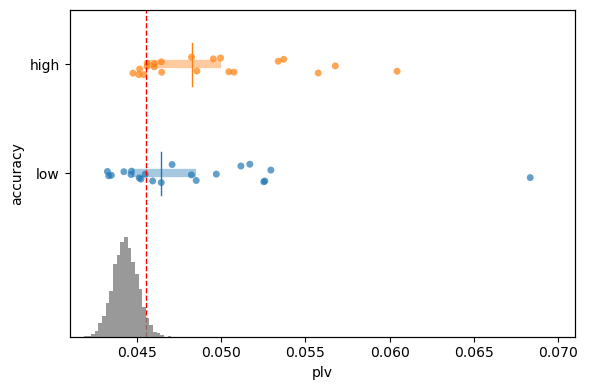

In [31]:
fig, ax = plt.subplots(figsize=(6,4))

# Plot 
plvs_130 = plvs[plvs.stim_freq == 130]
plvs_130 = plvs_130.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_130 = pd.concat([plvs_130, null])

sns.stripplot(
    ax = ax,
    data=plvs_130[plvs_130.accuracy_group!="null"],
    x="plv", y="accuracy_group", hue="accuracy_group",
    palette={"low": palette_tab10[0], "high": palette_tab10[1]},
    jitter=0.1, alpha = 0.7,
)
ax.legend
ax.set_ylim(-1.5, 1.5)
ax.set_xlim(0.041, 0.071)
ax.set_ylabel("accuracy")
ax.legend_.remove()

ax2 = ax.twinx()
ax2.hist(plvs_130[plvs_130.accuracy_group=="null"].plv, alpha = 0.8, color = 'grey', bins = 26)
ax2.set_ylim(0, 2000)
ax2.set_yticks([]) 
ax2.set_ylabel("")

colors = [palette_tab10[0], palette_tab10[1], 'black']
med = plvs_130.loc[plvs_130["accuracy_group"] == 'low', "plv"].median()
ax.plot([med, med], [0-0.2, 0+0.2], color=colors[0], lw=1)
ax.hlines(0, cis['low'][0], cis['low'][1], color=colors[0], linewidth=6, alpha = 0.4)

med = plvs_130.loc[plvs_130["accuracy_group"] == 'high', "plv"].median()
ax.plot([med, med], [1-0.2, 1+0.2], color=colors[1], lw=1)
ax.hlines(1, cis['high'][0], cis['high'][1], color=colors[1], linewidth=6, alpha = 0.4)

med = plvs_130.loc[plvs_130["accuracy_group"] == 'null', "plv"].median()
ax.axvline(x = CI95, lw = 1, linestyle = '--', color = 'red', zorder = 9)

plt.tight_layout()
plt.savefig("../figs/PLV-130-hz-scatter.png", dpi = 300)

**Tests**

In [32]:
high = plvs_130[plvs_130.accuracy_group == 'high']
low = plvs_130[plvs_130.accuracy_group == 'low']
null = plvs_130[plvs_130.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.8646854162216187, pvalue=0.0076875402592122555)
ShapiroResult(statistic=0.7548198103904724, pvalue=0.00014443541294895113)
ShapiroResult(statistic=0.9996377229690552, pvalue=0.5193954110145569)
compare groups
high vs null: u = 101468.0, p = 7.511376577335e-14, r = 0.10424971469755809
low vs null: u = 101468.0, p = 9.68059104298141e-07, r = 0.10424971469755809
high vs low: u = 273.0, p = 0.0954199528852176, r = 0.20378478648480558


### 200 Hz

In [33]:
plvs_200 = plvs[plvs.stim_freq == 200]
plvs_200 = plvs_200.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_200 = pd.concat([plvs_200, null])
cis = {}
bs = IIDBootstrap(plvs_200[plvs_200.accuracy_group == 'null'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['null'] = ci.tolist()
print("null BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_200[plvs_200.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['low'] = ci.tolist()
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_200[plvs_200.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['high'] = ci.tolist()
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
print(descriptives)

print(np.sum(plvs_200.plv[plvs_200.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'low'].tolist()[0]))
print(np.sum(plvs_200.plv[plvs_200.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'high'].tolist()[0]))

null BCa 95% CI: [0.04428029] [0.0443305]
low BCa 95% CI: [0.04527926] [0.0524093]
high BCa 95% CI: [0.04455771] [0.05296706]
  accuracy_group       med        Q1        Q3       IQR
0           high  0.049263  0.044558  0.057169  0.012611
1            low  0.048225  0.045279  0.056840  0.011560
2           null  0.044306  0.043815  0.044808  0.000993
0
0


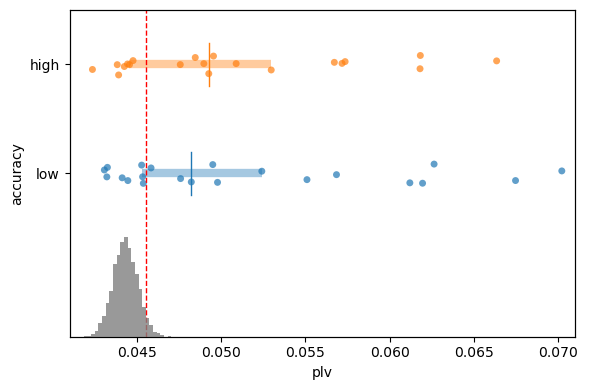

In [34]:
fig, ax = plt.subplots(figsize=(6,4))

# Plot 
plvs_200 = plvs[plvs.stim_freq == 200]
plvs_200 = plvs_200.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_200 = pd.concat([plvs_200, null])

sns.stripplot(
    ax = ax,
    data=plvs_200[plvs_200.accuracy_group!="null"],
    x="plv", y="accuracy_group", hue="accuracy_group",
    palette={"low": palette_tab10[0], "high": palette_tab10[1]},
    jitter=0.1, alpha = 0.7,
    # legend = False
)
ax.legend
ax.set_ylim(-1.5, 1.5)
ax.set_xlim(0.041, 0.071)
ax.set_ylabel("accuracy")
ax.legend_.remove()

ax2 = ax.twinx()
ax2.hist(plvs_200[plvs_200.accuracy_group=="null"].plv, alpha = 0.8, color = 'grey', bins = 26)
ax2.set_ylim(0, 2000)
ax2.set_yticks([]) 
ax2.set_ylabel("")

colors = [palette_tab10[0], palette_tab10[1], 'black']
med = plvs_200.loc[plvs_200["accuracy_group"] == 'low', "plv"].median()
ax.plot([med, med], [0-0.2, 0+0.2], color=colors[0], lw=1)
ax.hlines(0, cis['low'][0], cis['low'][1], color=colors[0], linewidth=6, alpha = 0.4)

med = plvs_200.loc[plvs_200["accuracy_group"] == 'high', "plv"].median()
ax.plot([med, med], [1-0.2, 1+0.2], color=colors[1], lw=1)
ax.hlines(1, cis['high'][0], cis['high'][1], color=colors[1], linewidth=6, alpha = 0.4)

med = plvs_200.loc[plvs_200["accuracy_group"] == 'null', "plv"].median()
ax.axvline(x = CI95, lw = 1, linestyle = '--', color = 'red', zorder = 9)

plt.tight_layout()
plt.savefig("../figs/PLV-200-hz-scatter.png", dpi = 300)

**Tests**

In [35]:
high = plvs_200[plvs_200.accuracy_group == 'high']
low = plvs_200[plvs_200.accuracy_group == 'low']
null = plvs_200[plvs_200.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.8890308141708374, pvalue=0.021566271781921387)
ShapiroResult(statistic=0.8595070242881775, pvalue=0.0062211547046899796)
ShapiroResult(statistic=0.9996377229690552, pvalue=0.5193954110145569)
compare groups
high vs null: u = 84834.0, p = 5.367950661212645e-07, r = 0.06883700120549835
low vs null: u = 84834.0, p = 6.910696800809852e-07, r = 0.06883700120549835
high vs low: u = 226.0, p = 0.449953551037655, r = 0.0213488823936463


### 280 Hz

In [36]:
plvs_280 = plvs[plvs.stim_freq == 280]
plvs_280 = plvs_280.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_280 = pd.concat([plvs_280, null])
cis = {}
bs = IIDBootstrap(plvs_280[plvs_280.accuracy_group == 'null'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['null'] = ci.tolist()
print("null BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_280[plvs_280.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['low'] = ci.tolist()
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_280[plvs_280.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['high'] = ci.tolist()
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
print(descriptives)

print(np.sum(plvs_280.plv[plvs_280.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'low'].tolist()[0]))
print(np.sum(plvs_280.plv[plvs_280.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'high'].tolist()[0]))

null BCa 95% CI: [0.04428091] [0.04433089]
low BCa 95% CI: [0.04559498] [0.05352069]
high BCa 95% CI: [0.04541733] [0.0492337]
  accuracy_group       med        Q1        Q3       IQR
0           high  0.048167  0.045417  0.049966  0.004548
1            low  0.048761  0.045595  0.054513  0.008918
2           null  0.044306  0.043815  0.044808  0.000993
0
0


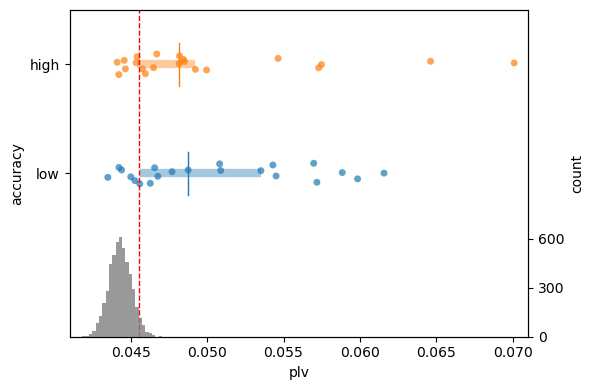

In [37]:
fig, ax = plt.subplots(figsize=(6.04,4))

# Plot 
plvs_280 = plvs[plvs.stim_freq == 280]
plvs_280 = plvs_280.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_280 = pd.concat([plvs_280, null])

sns.stripplot(
    ax = ax,
    data=plvs_280[plvs_280.accuracy_group!="null"],
    x="plv", y="accuracy_group", hue="accuracy_group",
    palette={"low": palette_tab10[0], "high": palette_tab10[1]},
    jitter=0.1, alpha = 0.7,
    # legend = False
)
ax.legend
ax.set_ylim(-1.5, 1.5)
ax.set_xlim(0.041, 0.071)
ax.set_ylabel("accuracy")
ax.legend_.remove()

ax2 = ax.twinx()
ax2.hist(plvs_280[plvs_280.accuracy_group=="null"].plv, alpha = 0.8, color = 'grey', bins = 26)
ax2.set_ylim(0, 2000)
ax2.set_yticks([0, 300, 600])
ax2.set_ylabel("count")

colors = [palette_tab10[0], palette_tab10[1], 'black']
med = plvs_280.loc[plvs_280["accuracy_group"] == 'low', "plv"].median()
ax.plot([med, med], [0-0.2, 0+0.2], color=colors[0], lw=1)
ax.hlines(0, cis['low'][0], cis['low'][1], color=colors[0], linewidth=6, alpha = 0.4)

med = plvs_280.loc[plvs_280["accuracy_group"] == 'high', "plv"].median()
ax.plot([med, med], [1-0.2, 1+0.2], color=colors[1], lw=1)
ax.hlines(1, cis['high'][0], cis['high'][1], color=colors[1], linewidth=6, alpha = 0.4)

med = plvs_280.loc[plvs_280["accuracy_group"] == 'null', "plv"].median()
ax.axvline(x = CI95, lw = 1, linestyle = '--', color = 'red', zorder = 9)

plt.tight_layout()
plt.savefig("../figs/PLV-280-hz-scatter.png", dpi = 300)

**Tests**

In [38]:
high = plvs_280[plvs_280.accuracy_group == 'high']
low = plvs_280[plvs_280.accuracy_group == 'low']
null = plvs_280[plvs_280.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.7698201537132263, pvalue=0.00023486574355047196)
ShapiroResult(statistic=0.9060486555099487, pvalue=0.04591077193617821)
ShapiroResult(statistic=0.9996377229690552, pvalue=0.5193954110145569)
compare groups
high vs null: u = 94977.0, p = 7.383579927958907e-11, r = 0.09043079421679821
low vs null: u = 94977.0, p = 1.662063582527228e-10, r = 0.09043079421679821
high vs low: u = 201.0, p = 0.6925582203638023, r = -0.07569149212292779
